In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

np.set_printoptions(precision=3, suppress=True)


In [ ]:
class Config:
    # system
    S = 3
    R = 50

    # horizons
    T_train = 12000
    T_eval  = 3000

    seed = 42

    # SLA delay thresholds (slots): [URLLC, eMBB, mMTC]
    D = np.array([2.0, 8.0, 20.0], dtype=float)

    # risk weights
    w = np.array([5.0, 1.0, 0.5], dtype=float)

    # CVaR
    alpha = 0.9

    # bootstrap replicas
    B = 20

    # two-timescale allocation
    K_alloc = 20

    # discrete action grid for each slice (IMPORTANT)
    A_grid = np.unique(np.clip(np.round(np.linspace(0, R, 12)).astype(int), 0, R))

    # load sweep
    load_grid = np.array([0.6, 0.8, 1.0, 1.2, 1.4], dtype=float)

    # causal logging exploration (positivity)
    eps_explore = 0.25

cfg = Config()
cfg.A_grid, cfg.load_grid


(array([ 0,  5,  9, 14, 18, 23, 27, 32, 36, 41, 45, 50]),
 array([0.6, 0.8, 1. , 1.2, 1.4]))

In [3]:
def snap_to_grid(a, A_grid):
    A_grid = np.asarray(A_grid, dtype=int)
    a = int(a)
    return int(A_grid[np.argmin(np.abs(A_grid - a))])

def cvar_alpha(samples, alpha=0.9):
    x = np.sort(np.asarray(samples))
    n = len(x)
    k = int(np.ceil(alpha*n)) - 1
    k = int(np.clip(k, 0, n-1))
    return float(x[k:].mean())

def realized_cvar(x, alpha=0.9):
    x = np.sort(np.asarray(x))
    n = len(x)
    k = int(np.ceil(alpha*n)) - 1
    k = int(np.clip(k, 0, n-1))
    return float(x[k:].mean())


In [4]:
class SimEnv:
    def __init__(self, cfg, load_mult=1.0, seed=None):
        self.cfg = cfg
        self.S = cfg.S
        self.R = cfg.R
        self.D = cfg.D.astype(float)
        self.load_mult = float(load_mult)
        self.rng = np.random.default_rng(cfg.seed if seed is None else seed)
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.S, dtype=float)
        self.cqi = self.rng.uniform(0.4, 0.9, size=self.S)

    def get_context(self):
        return {"Q": self.Q.copy(), "cqi": self.cqi.copy()}

    def _update_cqi(self):
        noise = self.rng.normal(0, 0.04, size=self.S)
        self.cqi = np.clip(
            0.92*self.cqi + 0.08*self.rng.uniform(0.3, 1.0, size=self.S) + noise,
            0.05, 1.0
        )

    def sample_arrivals(self):
        lam = np.zeros(self.S, dtype=float)

        # Slice 0: URLLC bursty
        base0 = 1.0
        burst = self.rng.binomial(1, 0.08) * self.rng.uniform(5, 15)
        jitter = max(0.0, self.rng.normal(0.0, 0.3))
        lam[0] = base0 + burst + jitter

        # Slice 1: eMBB smoother
        lam[1] = max(0.0, self.rng.normal(6.0, 1.0))

        # Slice 2: mMTC rare spikes
        lam[2] = self.rng.binomial(1, 0.02) * self.rng.uniform(30, 80)

        return self.load_mult * lam

    def service_rate(self, A):
        A = np.asarray(A, dtype=float)
        k = np.array([0.7, 1.0, 0.4])[:self.S]
        f = 0.5 + 1.5*(self.cqi ** 1.2)
        mu = k * np.sqrt(np.maximum(A, 0.0)) * f
        return mu

    def step(self, A):
        A = np.asarray(A, dtype=float)
        assert A.shape == (self.S,)
        assert A.sum() <= self.R + 1e-6

        self._update_cqi()
        lam = self.sample_arrivals()
        mu  = self.service_rate(A)

        Q_prev = self.Q.copy()
        self.Q = np.maximum(self.Q + lam - mu, 0.0)

        W = self.Q / (mu + 1e-6)              # delay proxy
        V = (W > self.D).astype(int)          # SLA violation
        served = np.minimum(Q_prev + lam, mu) # goodput proxy

        return self.get_context(), A.astype(int), lam, mu, W, V, served


In [5]:
def policy_equal(env, X, lam_hat=None):
    S, R = env.S, env.R
    A = np.full(S, R//S, dtype=int)
    for i in range(R - A.sum()):
        A[i % S] += 1
    # snap
    A = np.array([snap_to_grid(a, cfg.A_grid) for a in A], dtype=int)
    while A.sum() > R:
        i = np.argmax(A); A[i] = snap_to_grid(A[i]-1, cfg.A_grid)
    return A

def policy_proportional(env, X, lam_hat):
    S, R = env.S, env.R
    Q = X["Q"]
    score = 0.7*lam_hat + 0.3*(Q/(Q.sum()+1e-6))*lam_hat.sum()
    score = np.maximum(score, 1e-6)

    A = np.round(R*score/score.sum()).astype(int)

    while A.sum() > R:
        A[np.argmax(A)] -= 1
    while A.sum() < R:
        A[np.argmax(score - A)] += 1

    # snap to grid
    A = np.array([snap_to_grid(a, cfg.A_grid) for a in A], dtype=int)

    # ensure budget after snapping
    while A.sum() > R:
        i = np.argmax(A)
        feasible = cfg.A_grid[cfg.A_grid <= A[i]]
        A[i] = int(feasible[-2]) if len(feasible) >= 2 else 0
    while A.sum() < R:
        i = np.argmin(A)
        feasible = cfg.A_grid[cfg.A_grid >= A[i]]
        if len(feasible) >= 2:
            A[i] = int(feasible[1])
        else:
            break
        if A.sum() > R:
            A[i] = int(feasible[0])
            break
    return A

def policy_max_weight(env, X, lam_hat=None):
    S, R = env.S, env.R
    Q = X["Q"]
    A = np.zeros(S, dtype=int)
    for _ in range(R):
        best_s, best_gain = None, -1e18
        for s in range(S):
            gain = Q[s] * (np.sqrt(A[s]+1) - np.sqrt(A[s]))
            if gain > best_gain:
                best_gain = gain
                best_s = s
        A[best_s] += 1

    # snap + fix budget
    A = np.array([snap_to_grid(a, cfg.A_grid) for a in A], dtype=int)
    while A.sum() > R:
        i = np.argmax(A)
        feasible = cfg.A_grid[cfg.A_grid <= A[i]]
        A[i] = int(feasible[-2]) if len(feasible) >= 2 else 0
    return A


In [6]:
def epsilon_logging(env, X, lam_hat, eps=0.25):
   
    rng = env.rng
    if rng.uniform() > eps:
        return policy_proportional(env, X, lam_hat)

    g = np.asarray(cfg.A_grid, dtype=int)
    a0 = int(rng.choice(g))
    a1 = int(rng.choice(g))
    rem = env.R - (a0 + a1)
    if rem < 0:
        return policy_equal(env, X, lam_hat)
    feasible = g[g <= rem]
    a2 = int(feasible[np.argmin(np.abs(feasible - rem))]) if len(feasible) else 0
    return np.array([a0, a1, a2], dtype=int)


In [9]:
def enumerate_feasible_tuples(A_grid, R):
    g = list(map(int, A_grid))
    feas = []
    for a0 in g:
        for a1 in g:
            for a2 in g:
                if a0+a1+a2 <= R:
                    feas.append((a0,a1,a2))
    return np.array(feas, dtype=int)

FEAS_TUPLES = enumerate_feasible_tuples(cfg.A_grid, cfg.R)
Pr_random_tuple = 1.0 / len(FEAS_TUPLES)

def pi_b_tuple(A_tuple, A_base, eps):
    # epsilon-mixture: (1-eps)*I[A=A_base] + eps*Uniform(feasible tuples)
    p = eps * Pr_random_tuple
    if np.all(A_tuple == A_base):
        p += (1.0 - eps)
    return float(p)

def generate_causal_logs(env, T, eps=0.25, seed=0):
    rng = np.random.default_rng(seed)
    env.reset()
    rows = []

    lam_mu = np.array([2.0, 6.0, 1.0])[:env.S]
    lam_sd = np.array([1.0, 1.0, 1.0])[:env.S]

    for t in range(T):
        X = env.get_context()
        lam_hat = np.maximum(0.0, rng.normal(lam_mu, lam_sd))

        A_base = policy_proportional(env, X, lam_hat)
        A = epsilon_logging(env, X, lam_hat, eps=eps)
        p_tuple = pi_b_tuple(A, A_base, eps)

        X2, A, lam, mu, W, V, served = env.step(A)

        for s in range(env.S):
            rows.append({
                "t": t, "s": s,
                "A": int(A[s]),
                "pi_b_tuple": float(p_tuple),
                "lam": float(lam[s]),
                "cqi": float(X2["cqi"][s]),
                "Q": float(X2["Q"][s]),
                "V": int(V[s]),
                "W": float(W[s]),
                "mu": float(mu[s]),
                "served": float(served[s]),
            })
    return pd.DataFrame(rows)

env_train = SimEnv(cfg, load_mult=1.0, seed=cfg.seed)
df_train = generate_causal_logs(env_train, cfg.T_train, eps=cfg.eps_explore, seed=cfg.seed)
df_train.head(), df_train["A"].unique()[:10]


(   t  s   A  pi_b_tuple       lam       cqi         Q  V         W        mu  \
 0  0  0  14    0.750716  1.000000  0.720904  0.000000  0  0.000000  3.962392   
 1  0  1  27    0.750716  6.368751  0.486548  0.487270  0  0.082848  5.881481   
 2  0  2   9    0.750716  0.000000  0.842721  0.000000  0  0.000000  2.065862   
 3  1  0  14    0.750716  1.123820  0.729852  0.000000  0  0.000000  4.001953   
 4  1  1  36    0.750716  6.430821  0.487977  0.113382  0  0.016662  6.804710   
 
      served  
 0  1.000000  
 1  5.881481  
 2  0.000000  
 3  1.123820  
 4  6.804710  ,
 array([14, 27,  9, 36,  0,  5, 32, 41, 23, 18]))

In [10]:
A_grid = np.asarray(cfg.A_grid, dtype=int)
A_to_idx = {int(a): i for i, a in enumerate(A_grid)}
idx_to_A = {i: int(a) for i, a in enumerate(A_grid)}

def make_slice_df(df, s):
    d = df[df["s"]==s].copy()
    d["A"] = d["A"].apply(lambda a: snap_to_grid(a, A_grid))
    d["A_idx"] = d["A"].map(A_to_idx)
    d = d.dropna(subset=["A_idx"]).copy()
    d["A_idx"] = d["A_idx"].astype(int)
    return d

# sanity: should be 0 bad values
bad = set(df_train["A"].unique()) - set(A_grid)
print("A values not in grid:", bad)


A values not in grid: set()


In [11]:
for s in range(cfg.S):
    df_slice = make_slice_df(df_train, s)
    df_slice.to_csv(f"processed_slice_{s}.csv", index=False)


In [12]:
class PropensityModel:
    # multinomial logistic regression for e(a|X)
    def __init__(self, seed=0):
        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=4000, multi_class="auto", random_state=seed))
        ])

    def fit(self, df_s):
        X = df_s[["cqi","Q","lam"]].values
        y = df_s["A_idx"].values
        self.model.fit(X, y)
        return self

    def proba(self, cqi, Q, lam):
        X = np.column_stack([cqi, Q, lam])
        return self.model.predict_proba(X)  # (n, |A_grid|)

class OutcomeModel:
    # RandomForest classifier for m(a,X)=P(V=1|A=a,X)
    def __init__(self, seed=0):
        self.model = RandomForestClassifier(
            n_estimators=300, max_depth=12, random_state=seed, n_jobs=-1
        )

    def fit(self, df_s):
        X = df_s[["A","cqi","Q","lam"]].values
        y = df_s["V"].values
        self.model.fit(X, y)
        return self

    def p_violate(self, A, cqi, Q, lam):
        X = np.column_stack([A, cqi, Q, lam])
        return self.model.predict_proba(X)[:,1]


In [13]:
def train_boot_causal(df, B=20, seed=0):
    rng = np.random.default_rng(seed)
    n = len(df)
    boot = []
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        dfi = df.iloc[idx]
        per_slice = {}
        for s in range(cfg.S):
            ds = make_slice_df(dfi, s)
            e = PropensityModel(seed=seed+100*b+s).fit(ds)
            m = OutcomeModel(seed=seed+100*b+s+999).fit(ds)
            per_slice[s] = (e, m)
        boot.append(per_slice)
    return boot

boot_causal = train_boot_causal(df_train, B=cfg.B, seed=cfg.seed)
len(boot_causal)


20

In [14]:
def css_allocate_full_causal(env, X, lam_hat, boot_causal, weights, alpha=0.9, A_grid=None):
    S, R = env.S, env.R
    w = np.asarray(weights[:S], dtype=float)
    if A_grid is None:
        A_grid = cfg.A_grid
    A_grid = np.asarray(A_grid, dtype=int)
    M = len(A_grid)

    cost = np.zeros((S, M), dtype=float)

    for s in range(S):
        cqi_s = float(X["cqi"][s])
        Q_s   = float(X["Q"][s])
        lam_s = float(lam_hat[s])

        preds = []
        for b in range(len(boot_causal)):
            _, m = boot_causal[b][s]
            A_vec   = A_grid.astype(float)
            cqi_vec = np.full(M, cqi_s)
            Q_vec   = np.full(M, Q_s)
            lam_vec = np.full(M, lam_s)
            preds.append(m.p_violate(A_vec, cqi_vec, Q_vec, lam_vec))  # m(a,X) = P(V|do(A=a),X)

        preds = np.asarray(preds)  # (B, M)
        for j in range(M):
            cost[s, j] = w[s] * cvar_alpha(preds[:, j], alpha=alpha)

    best_obj = 1e18
    best_A = None
    for i,a0 in enumerate(A_grid):
        for j,a1 in enumerate(A_grid):
            for k,a2 in enumerate(A_grid):
                if a0+a1+a2 <= R:
                    obj = cost[0,i] + cost[1,j] + cost[2,k]
                    if obj < best_obj:
                        best_obj = obj
                        best_A = np.array([a0,a1,a2], dtype=int)

    A = best_A.copy()
    while A.sum() < R:
        A[np.argmin(A)] += 1
    return A


In [15]:
def run_policy_detailed(env, T, policy_name, boot_causal=None, K_alloc=20, seed=0):
    rng = np.random.default_rng(seed)
    env.reset()

    lam_mu = np.array([2.0, 6.0, 1.0])[:env.S]
    lam_sd = np.array([1.0, 1.0, 1.0])[:env.S]

    A_cached = None
    t_ms = []

    V_mean_series = []
    V_ts = np.zeros((T, env.S))
    W_ts = np.zeros((T, env.S))
    served_ts = np.zeros((T, env.S))
    A_ts = np.zeros((T, env.S), dtype=int)

    for t in range(T):
        X = env.get_context()
        lam_hat = np.maximum(0.0, rng.normal(lam_mu, lam_sd))

        t0 = time.perf_counter()
        if policy_name == "equal":
            A = policy_equal(env, X, lam_hat)
        elif policy_name == "proportional":
            A = policy_proportional(env, X, lam_hat)
        elif policy_name == "max_weight":
            A = policy_max_weight(env, X, lam_hat)
        elif policy_name == "css_full_causal":
            if (A_cached is None) or (t % K_alloc == 0):
                A_cached = css_allocate_full_causal(env, X, lam_hat, boot_causal, cfg.w, cfg.alpha, cfg.A_grid)
            A = A_cached
        else:
            raise ValueError("unknown policy")
        t1 = time.perf_counter()
        t_ms.append((t1 - t0) * 1000.0)

        _, A, lam, mu, W, V, served = env.step(A)

        V_mean_series.append(np.mean(V))
        V_ts[t,:] = V
        W_ts[t,:] = W
        served_ts[t,:] = served
        A_ts[t,:] = A

    V_mean_series = np.asarray(V_mean_series)
    metrics = {
        "V_mean": float(V_mean_series.mean()),
        "V_CVaR": float(realized_cvar(V_mean_series, cfg.alpha)),
        "URLLC_V_mean": float(V_ts[:,0].mean()),
        "eMBB_V_mean":  float(V_ts[:,1].mean()),
        "mMTC_V_mean":  float(V_ts[:,2].mean()),
        "URLLC_W_mean": float(W_ts[:,0].mean()),
        "goodput_mean": float(served_ts.mean()),
        "eMBB_goodput": float(served_ts[:,1].mean()),
        "decision_ms_mean": float(np.mean(t_ms)),
        "decision_ms_p95": float(np.percentile(t_ms, 95)),
    }
    traces = {
        "V_mean_series": V_mean_series,
        "V_ts": V_ts,
        "W_ts": W_ts,
        "served_ts": served_ts,
        "A_ts": A_ts,
    }
    return metrics, traces


In [16]:
policies = ["equal", "proportional", "max_weight", "css_full_causal"]
env_eval = SimEnv(cfg, load_mult=1.0, seed=cfg.seed+999)

results, traces = {}, {}
for p in policies:
    m, tr = run_policy_detailed(env_eval, cfg.T_eval, p, boot_causal=boot_causal, K_alloc=cfg.K_alloc, seed=cfg.seed+1)
    results[p] = m
    traces[p] = tr

table_summary_load1 = pd.DataFrame(results).T
table_summary_load1


,V_mean,V_CVaR,URLLC_V_mean,eMBB_V_mean,mMTC_V_mean,URLLC_W_mean,goodput_mean,eMBB_goodput,decision_ms_mean,decision_ms_p95
equal,0.371444,0.741971,0.074667,0.645000,0.394667,3.895447e-01,3.080150,5.901733,0.010330,0.011913
proportional,0.091111,0.400886,0.159333,0.000000,0.114000,7.684534e+04,2.946519,5.992234,0.017602,0.022489
max_weight,0.294000,0.786268,0.539333,0.249333,0.093333,1.424035e+06,2.855194,6.001126,0.184770,0.190459
css_full_causal,0.255667,0.718715,0.097000,0.220333,0.449667,5.024542e-01,2.947391,5.965833,239.655829,129.209353


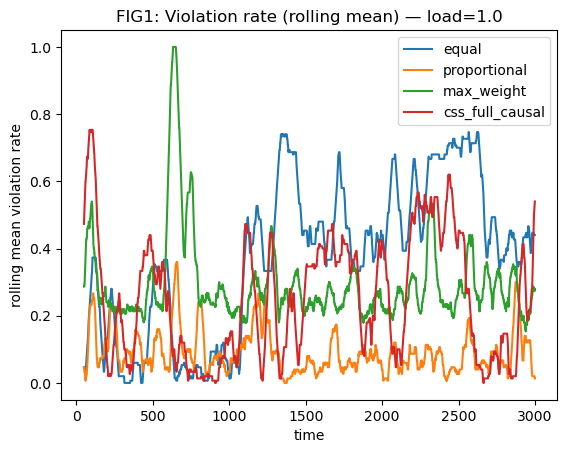

In [17]:
plt.figure()
for p in policies:
    plt.plot(pd.Series(traces[p]["V_mean_series"]).rolling(50).mean(), label=p)
plt.xlabel("time")
plt.ylabel("rolling mean violation rate")
plt.legend()
plt.title("FIG1: Violation rate (rolling mean) — load=1.0")
plt.show()


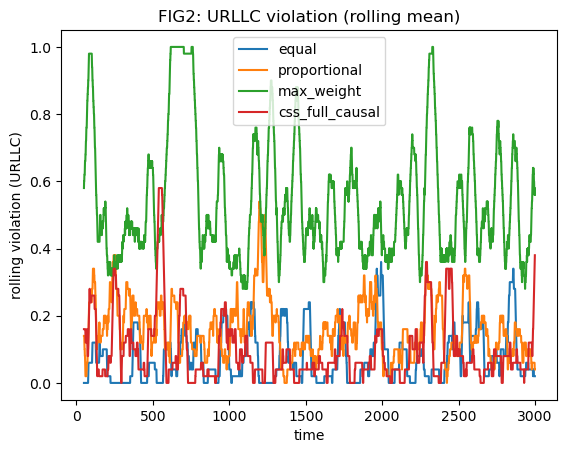

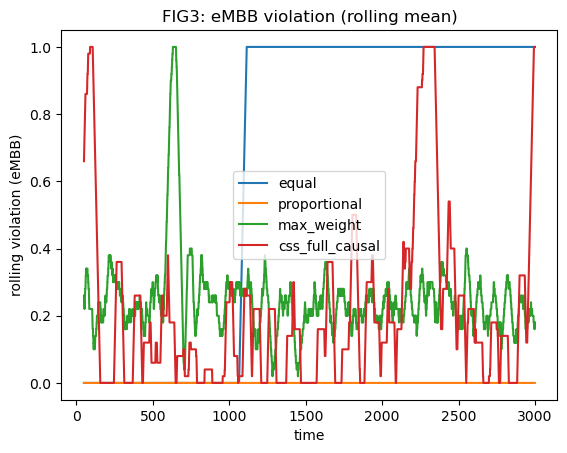

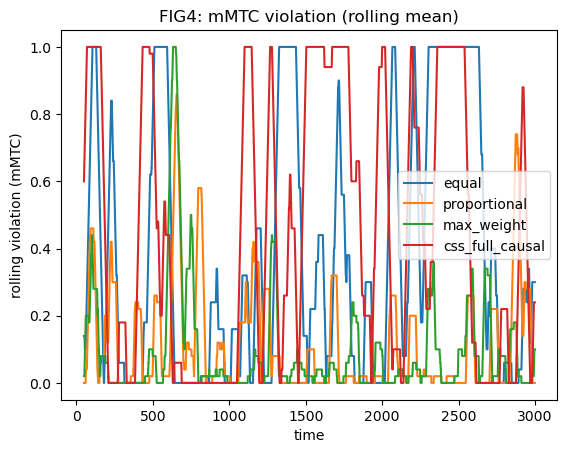

In [18]:
win = 50

plt.figure()
for p in policies:
    plt.plot(pd.Series(traces[p]["V_ts"][:,0]).rolling(win).mean(), label=p)
plt.xlabel("time"); plt.ylabel("rolling violation (URLLC)")
plt.legend(); plt.title("FIG2: URLLC violation (rolling mean)")
plt.show()

plt.figure()
for p in policies:
    plt.plot(pd.Series(traces[p]["V_ts"][:,1]).rolling(win).mean(), label=p)
plt.xlabel("time"); plt.ylabel("rolling violation (eMBB)")
plt.legend(); plt.title("FIG3: eMBB violation (rolling mean)")
plt.show()

plt.figure()
for p in policies:
    plt.plot(pd.Series(traces[p]["V_ts"][:,2]).rolling(win).mean(), label=p)
plt.xlabel("time"); plt.ylabel("rolling violation (mMTC)")
plt.legend(); plt.title("FIG4: mMTC violation (rolling mean)")
plt.show()


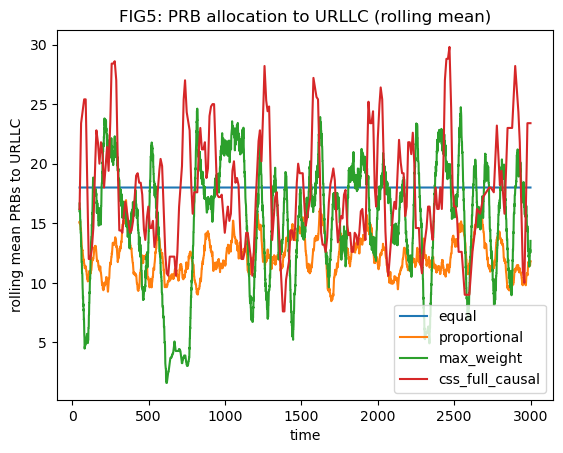

In [19]:
plt.figure()
for p in policies:
    plt.plot(pd.Series(traces[p]["A_ts"][:,0]).rolling(50).mean(), label=p)
plt.xlabel("time")
plt.ylabel("rolling mean PRBs to URLLC")
plt.legend()
plt.title("FIG5: PRB allocation to URLLC (rolling mean)")
plt.show()


In [22]:
def sweep_over_load(cfg, boot_causal, policies):
    rows = []
    for lm in cfg.load_grid:
        for p in policies:
            env = SimEnv(cfg, load_mult=float(lm), seed=cfg.seed + int(1000*lm) + 7)
            m, _ = run_policy_detailed(env, cfg.T_eval, p, boot_causal=boot_causal, K_alloc=cfg.K_alloc, seed=cfg.seed+3)
            rows.append({"load_mult": float(lm), "policy": p, **m})
    return pd.DataFrame(rows)

df_sweep = sweep_over_load(cfg, boot_causal, policies)
df_sweep


,load_mult,policy,V_mean,V_CVaR,URLLC_V_mean,eMBB_V_mean,mMTC_V_mean,URLLC_W_mean,goodput_mean,eMBB_goodput,decision_ms_mean,decision_ms_p95
0,0.6,equal,0.022444,0.223699,0.004667,0.000000,0.062667,8.258223e-02,1.778293,3.589393,0.009444,0.010571
1,0.6,proportional,0.031111,0.310078,0.053000,0.000000,0.040333,4.594225e+04,1.778394,3.589393,0.016867,0.021374
2,0.6,max_weight,0.320889,0.512735,0.511000,0.430333,0.021333,8.321143e+05,1.778115,3.587154,0.182090,0.186014
3,0.6,css_full_causal,0.010889,0.108527,0.004667,0.000000,0.028000,8.353798e-02,1.778428,3.589393,262.332059,148.306105
4,0.8,equal,0.062000,0.341085,0.027667,0.000000,0.158333,2.140224e-01,2.432966,4.810947,0.009462,0.012432
5,0.8,proportional,0.073444,0.384275,0.101667,0.000000,0.118667,7.518444e+04,2.433418,4.811019,0.016896,0.021520
6,0.8,max_weight,0.308556,0.720930,0.535000,0.319667,0.071000,1.471925e+06,2.433035,4.808702,0.186886,0.196855
7,0.8,css_full_causal,0.068111,0.393134,0.042667,0.045667,0.116000,2.694594e-01,2.433181,4.810613,264.474526,157.002822
8,1.0,equal,0.315222,0.707641,0.062333,0.624667,0.258667,3.380591e-01,2.943657,5.923828,0.009525,0.011853
9,1.0,proportional,0.121556,0.489480,0.151667,0.000000,0.213000,1.012389e+05,2.968308,5.997782,0.016355,0.020891


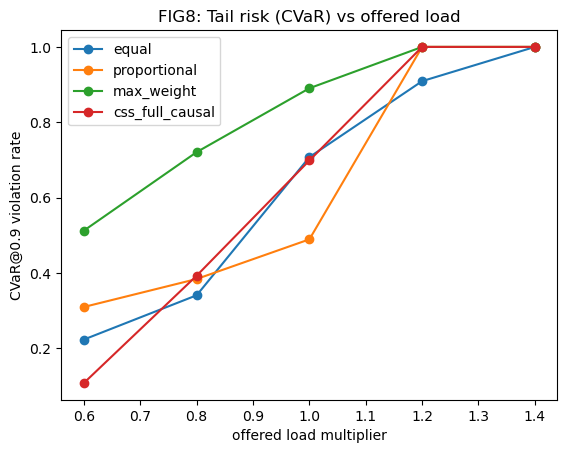

In [23]:
plt.figure()
for p in policies:
    d = df_sweep[df_sweep["policy"]==p].sort_values("load_mult")
    plt.plot(d["load_mult"], d["V_CVaR"], marker="o", label=p)
plt.xlabel("offered load multiplier")
plt.ylabel(f"CVaR@{cfg.alpha} violation rate")
plt.legend()
plt.title("FIG8: Tail risk (CVaR) vs offered load")
plt.show()


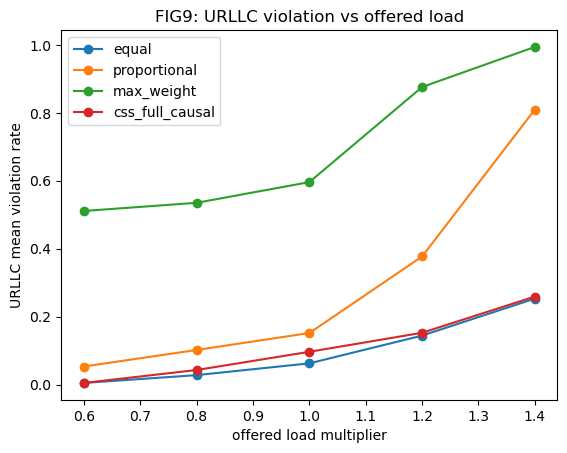

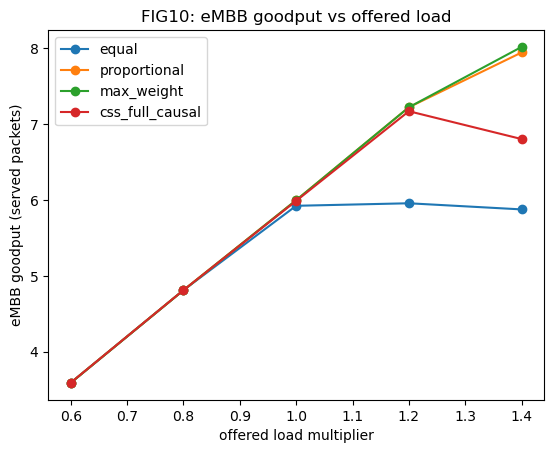

In [24]:
plt.figure()
for p in policies:
    d = df_sweep[df_sweep["policy"]==p].sort_values("load_mult")
    plt.plot(d["load_mult"], d["URLLC_V_mean"], marker="o", label=p)
plt.xlabel("offered load multiplier")
plt.ylabel("URLLC mean violation rate")
plt.legend()
plt.title("FIG9: URLLC violation vs offered load")
plt.show()

plt.figure()
for p in policies:
    d = df_sweep[df_sweep["policy"]==p].sort_values("load_mult")
    plt.plot(d["load_mult"], d["eMBB_goodput"], marker="o", label=p)
plt.xlabel("offered load multiplier")
plt.ylabel("eMBB goodput (served packets)")
plt.legend()
plt.title("FIG10: eMBB goodput vs offered load")
plt.show()


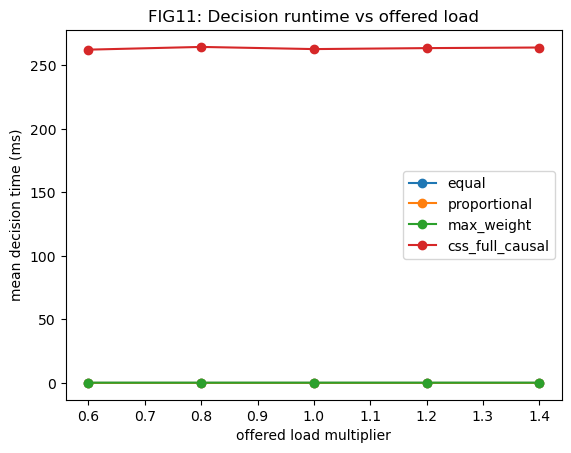

In [25]:
plt.figure()
for p in policies:
    d = df_sweep[df_sweep["policy"]==p].sort_values("load_mult")
    plt.plot(d["load_mult"], d["decision_ms_mean"], marker="o", label=p)
plt.xlabel("offered load multiplier")
plt.ylabel("mean decision time (ms)")
plt.legend()
plt.title("FIG11: Decision runtime vs offered load")
plt.show()


In [26]:
table_settings = pd.DataFrame([{
    "S": cfg.S, "R": cfg.R, "T_train": cfg.T_train, "T_eval": cfg.T_eval,
    "D_URLLC": cfg.D[0], "D_eMBB": cfg.D[1], "D_mMTC": cfg.D[2],
    "alpha": cfg.alpha, "B": cfg.B, "K_alloc": cfg.K_alloc,
    "A_grid": cfg.A_grid.tolist(), "load_grid": cfg.load_grid.tolist(),
    "eps_explore": cfg.eps_explore
}])

max_load = float(cfg.load_grid.max())
table_summary_maxload = (df_sweep[df_sweep["load_mult"]==max_load]
                         .set_index("policy")[["V_mean","V_CVaR","URLLC_V_mean","URLLC_W_mean","eMBB_goodput","decision_ms_mean"]])

table_settings, table_summary_maxload


(   S   R  T_train  T_eval  D_URLLC  D_eMBB  D_mMTC  alpha   B  K_alloc  \
 0  3  50    12000    3000      2.0     8.0    20.0    0.9  20       20   
 
                                           A_grid                  load_grid  \
 0  [0, 5, 9, 14, 18, 23, 27, 32, 36, 41, 45, 50]  [0.6, 0.8, 1.0, 1.2, 1.4]   
 
    eps_explore  
 0         0.25  ,
                    V_mean  V_CVaR  URLLC_V_mean  URLLC_W_mean  eMBB_goodput  \
 policy                                                                        
 equal            0.603222     1.0      0.253000  1.388516e+00      5.876145   
 proportional     0.920222     1.0      0.809667  1.474801e+06      7.946315   
 max_weight       0.987556     1.0      0.994000  3.742190e+05      8.019616   
 css_full_causal  0.746667     1.0      0.259000  4.256804e+05      6.804136   
 
                  decision_ms_mean  
 policy                             
 equal                    0.009404  
 proportional             0.016620  
 max_weight        

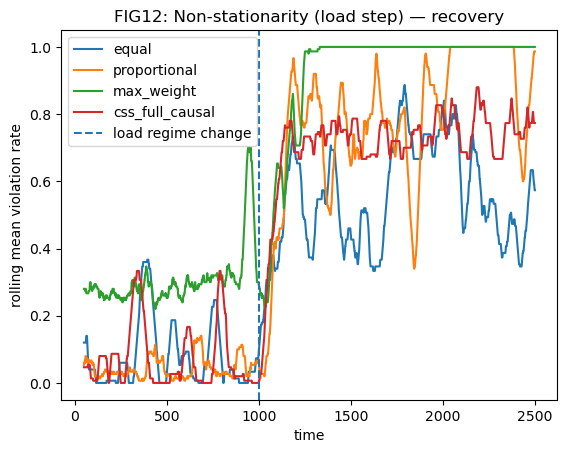

In [27]:
def run_regime_change(env, T, policy_name, boot_causal=None, K_alloc=20, seed=0, t0=1000, lm1=0.8, lm2=1.4):
    rng = np.random.default_rng(seed)
    env.reset()
    lam_mu = np.array([2.0, 6.0, 1.0])[:env.S]
    lam_sd = np.array([1.0, 1.0, 1.0])[:env.S]
    A_cached = None
    V_series = []

    for t in range(T):
        env.load_mult = lm1 if t < t0 else lm2
        X = env.get_context()
        lam_hat = np.maximum(0.0, rng.normal(lam_mu, lam_sd))

        if policy_name == "equal":
            A = policy_equal(env, X, lam_hat)
        elif policy_name == "proportional":
            A = policy_proportional(env, X, lam_hat)
        elif policy_name == "max_weight":
            A = policy_max_weight(env, X, lam_hat)
        elif policy_name == "css_full_causal":
            if (A_cached is None) or (t % K_alloc == 0):
                A_cached = css_allocate_full_causal(env, X, lam_hat, boot_causal, cfg.w, cfg.alpha, cfg.A_grid)
            A = A_cached
        else:
            raise ValueError

        _, _, _, _, _, V, _ = env.step(A)
        V_series.append(np.mean(V))
    return np.asarray(V_series)

T_reg = 2500
env_reg = SimEnv(cfg, load_mult=1.0, seed=cfg.seed+2024)

plt.figure()
for p in policies:
    v = run_regime_change(env_reg, T_reg, p, boot_causal=boot_causal, K_alloc=cfg.K_alloc, seed=cfg.seed+88, t0=1000, lm1=0.8, lm2=1.4)
    plt.plot(pd.Series(v).rolling(50).mean(), label=p)
plt.axvline(1000, linestyle="--", label="load regime change")
plt.xlabel("time")
plt.ylabel("rolling mean violation rate")
plt.legend()
plt.title("FIG12: Non-stationarity (load step) — recovery")
plt.show()
